In [3]:
import pickle
import re
import sys
from pathlib import Path

import cairosvg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import scanpy as sc

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.PerSamplePathwayAnalysis.pathway_convergence import gene_sig_at_q
from MixedEffectsModeling.SignalTrendAnalysis.sankey_helpers import strip_reactome_code
from MixedEffectsModeling.SignalTrendAnalysis.run_leading_edge_pattern import CURDIR, SLUG_MAP, Z_THRESH, parse_curation
    
PCDIR = config.PATHWAY_CONV_DIR  # sig.pkl/universe.pkl live in PerSamplePathwayAnalysis, not here
FIGDIR = config.SIGNAL_TREND_FIG_DIR
FIGDIR.mkdir(parents=True, exist_ok=True)

heat_data = pickle.load(open(CURDIR / 'leading_edge_pattern_data.pkl', 'rb'))
summary = pd.read_csv(CURDIR / 'leading_edge_pattern_summary.csv')

In [4]:
DEFAULT_PATIENT_COLOR = '#737373'
MIN_ALPHA = 0.15
MAX_ALPHA = 0.80
SEVERITY_COL = 'Stage/Condition'
SEVERITY_COLORS = {'PDAC': '#d55e00', 'IPMN': '#0072b2', 'Islet Cell Tumor': '#009e73'}
DISPLAY_NAME = {
    'Tuberculosis': 'Tuberculosis', 'Pancreatitis': 'Pancreatitis', 'Pancreatic_Cancer': 'Pancreatic Cancer',
    'Pre-eclampsia': 'Pre-eclampsia', 'Colorectal_Cancer': 'Colorectal Cancer', 'Lung_Cancer': 'Lung Cancer',
    'Esophagus_Cancer': 'Esophagus Cancer', 'Stomach_Cancer': 'Stomach Cancer',
    'Liver_Cancer_Roskams-Hieter': 'Liver Cancer (Roskams-Hieter)', 'Liver_Cancer_Chen': 'Liver Cancer (Chen)',
}

MAX_GENES_PER_PATHWAY = 12
HISTONE_FAMILY_CAP = 2
histone_rx = re.compile(r'^(H1|H2A|H2B|H3|H4)')


def gene_family(sym):
    m = histone_rx.match(sym)
    return m.group(1) if m else sym


def hex_to_rgba(hex_str, a):
    r, g, b = (int(hex_str.lstrip('#')[k:k + 2], 16) for k in (0, 2, 4))
    return f'rgba({r},{g},{b},{a})'


def build_sankey(stem):
    gsea_file, terms = parse_curation(CURDIR / f'{stem}.md')
    slug = SLUG_MAP[stem]
    pdir = PCDIR / slug
    d = pickle.load(open(pdir / 'sig.pkl', 'rb'))
    names_c = d['names_c']
    disp_name = DISPLAY_NAME[stem]
    Zu, Fm = pickle.load(open(pdir / 'universe.pkl', 'rb'))
    sym2idx = {s: i for i, s in enumerate(d['universe_syms'])}
    # [수정] 기존 BH FDR 유의성 계산(bh_sig) 제거

    if stem == 'Pancreatic_Cancer':
        severity = sc.read_h5ad(config.H5AD_PATH, backed='r').obs[SEVERITY_COL].reindex(names_c).values
        pat_color = lambda i: SEVERITY_COLORS.get(severity[i], DEFAULT_PATIENT_COLOR)
        pat_label = lambda i: f'{disp_name} {i + 1}' + (f' ({severity[i]})' if pd.notna(severity[i]) else '')
    else:
        pat_color = lambda i: DEFAULT_PATIENT_COLOR
        pat_label = lambda i: f'{disp_name} {i + 1}'

    cmap = plt.get_cmap('tab20')
    PATH_COLORS = [f'#{"".join(f"{int(c * 255):02x}" for c in cmap(ti % 20)[:3])}' for ti in range(len(terms))]

    pathway_gene_edges = {ti: {} for ti in range(len(terms))}
    for ti, term in enumerate(terms):
        key = (stem, term)
        if key not in heat_data:
            continue
        Zsub, genes = heat_data[key]
        hit = np.abs(Zsub) > Z_THRESH
        if not hit.any():
            continue
        strength = np.where(hit, np.abs(Zsub), 0).sum(axis=0)
        deg = hit.sum(axis=0)
        order = np.lexsort((-strength, -deg))
        picked, family_count = [], {}
        for gc in order:
            if strength[gc] == 0:
                continue
            fam = gene_family(genes[gc])
            if family_count.get(fam, 0) >= HISTONE_FAMILY_CAP:
                continue
            picked.append(gc)
            family_count[fam] = family_count.get(fam, 0) + 1
            if len(picked) == MAX_GENES_PER_PATHWAY:
                break
        for gc in picked:
            edges = {i: Zsub[i, gc] for i in range(len(names_c)) if hit[i, gc]}
            if edges:
                pathway_gene_edges[ti][genes[gc]] = edges

    gene_strength = {}
    for ti, edges_by_gene in pathway_gene_edges.items():
        for gname, edges in edges_by_gene.items():
            gene_strength.setdefault(gname, {})[ti] = sum(abs(z) for z in edges.values())
    if not gene_strength:
        print(f'{stem}: no gene edges survived Z_THRESH, skipping')
        return

    gene_primary_ti = {g: max(dd, key=dd.get) for g, dd in gene_strength.items()}
    displayed_genes = sorted(gene_strength, key=lambda g: (gene_primary_ti[g], -gene_strength[g][gene_primary_ti[g]]))

    pat_gene_z = {}
    for edges_by_gene in pathway_gene_edges.values():
        for gname, edges in edges_by_gene.items():
            for i, z in edges.items():
                pat_gene_z[(i, gname)] = abs(z)

    gene_col = {g: k for k, g in enumerate(displayed_genes)}
    pat_gene_weight = {}
    for (i, gname), z in pat_gene_z.items():
        pat_gene_weight.setdefault(i, {})[gname] = z
    pat_sort_key = {}
    for i, gw in pat_gene_weight.items():
        primary_g = max(gw, key=gw.get)
        pat_sort_key[i] = (gene_col[primary_g], -gw[primary_g])
    displayed_pats = sorted(pat_sort_key, key=pat_sort_key.get)
    used_ti = sorted({ti for ti, e in pathway_gene_edges.items() if e})

    pat_pos = {i: k for k, i in enumerate(displayed_pats)}
    gene_pos = {g: k for k, g in enumerate(displayed_genes)}
    path_pos = {ti: k for k, ti in enumerate(used_ti)}
    n_pat_d, n_gene_d = len(displayed_pats), len(displayed_genes)
    n_pat_total = len(names_c)

    node_labels = ([pat_label(i) for i in displayed_pats] + displayed_genes
                  + [strip_reactome_code(terms[ti]) for ti in used_ti])
    node_colors = ([pat_color(i) for i in displayed_pats] + [PATH_COLORS[gene_primary_ti[g]] for g in displayed_genes]
                  + [PATH_COLORS[ti] for ti in used_ti])

    z_vals = list(pat_gene_z.values())
    z_min, z_max = (min(z_vals), max(z_vals)) if z_vals else (Z_THRESH, Z_THRESH + 1.0)

    src, tgt, val, link_col = [], [], [], []
    for (i, gname), z in pat_gene_z.items():
        src.append(pat_pos[i])
        tgt.append(n_pat_d + gene_pos[gname])
        val.append(z)
        
        alpha = MIN_ALPHA + (MAX_ALPHA - MIN_ALPHA) * ((z - z_min) / (z_max - z_min)) if z_max > z_min else MAX_ALPHA
        link_col.append(hex_to_rgba(pat_color(i), round(alpha, 3)))

    gene_in_total = {}
    for (i, gname), z in pat_gene_z.items():
        gene_in_total[gname] = gene_in_total.get(gname, 0) + z
    gene_out_raw = {}
    for ti, edges_by_gene in pathway_gene_edges.items():
        if ti not in path_pos:
            continue
        for gname, edges in edges_by_gene.items():
            gene_out_raw[gname] = gene_out_raw.get(gname, 0) + sum(abs(z) for z in edges.values())

    for ti, edges_by_gene in pathway_gene_edges.items():
        if ti not in path_pos:
            continue
        for gname, edges in edges_by_gene.items():
            raw = sum(abs(z) for z in edges.values())
            scale = gene_in_total[gname] / gene_out_raw[gname] if gene_out_raw[gname] else 1.0
            src.append(n_pat_d + gene_pos[gname])
            tgt.append(n_pat_d + n_gene_d + path_pos[ti])
            val.append(raw * scale)
            link_col.append(hex_to_rgba(PATH_COLORS[ti], 0.45))

    link_order = sorted(range(len(src)), key=lambda k: (tgt[k], src[k]))
    src = [src[k] for k in link_order]
    tgt = [tgt[k] for k in link_order]
    val = [val[k] for k in link_order]
    link_col = [link_col[k] for k in link_order]

    fig = go.Figure(go.Sankey(
        arrangement='snap',
        node=dict(label=node_labels, color=node_colors, pad=5, thickness=12, line=dict(width=0)),
        link=dict(source=src, target=tgt, value=val, color=link_col),
    ))
    
    fig.update_layout(width=1200, height=max(700, (n_pat_d + n_gene_d) * 13), font_size=11,
                      title=f'{disp_name}: patient -> leading-edge gene -> pathway'
                            f'<br><sup>Link opacity dynamically scaled by |Z| score (|Z| range: {z_min:.2f} ~ {z_max:.2f})</sup>')

    svg = fig.to_image(format='svg').decode('utf-8')
    svg = re.sub(r'text-shadow:[^;"]*;', '', svg)
    out_path = FIGDIR / f'{stem}_sankey.png'
    cairosvg.svg2png(bytestring=svg.encode('utf-8'), write_to=str(out_path), scale=2)
    print(f'{disp_name}: {n_pat_d}/{n_pat_total} patients shown, {n_gene_d} genes, '
          f'{len(used_ti)}/{len(terms)} pathways -> {out_path}')
    return fig

In [ ]:
for stem in SLUG_MAP:
    fig = build_sankey(stem)
    if fig is not None:
        fig.show()

In [31]:
import pickle

import numpy as np
import pandas as pd

import MixedEffectsModeling.config as config
from MixedEffectsModeling.PerSamplePathwayAnalysis.pathway_convergence import gene_sig_at_q
from MixedEffectsModeling.SignalTrendAnalysis.run_leading_edge_pattern import CURDIR, SLUG_MAP, parse_curation

PCDIR = config.PATHWAY_CONV_DIR
OUT_PATH = CURDIR / "sankey5_edges.csv"
CATEGORY = {
    "Tuberculosis": "inflammatory", "Pancreatitis": "inflammatory", "Pre-eclampsia": "inflammatory",
    "Pancreatic_Cancer": "cancer", "Colorectal_Cancer": "cancer", "Lung_Cancer": "cancer",
    "Esophagus_Cancer": "cancer", "Stomach_Cancer": "cancer",
    "Liver_Cancer_Roskams-Hieter": "cancer", "Liver_Cancer_Chen": "cancer",
}
HIPPO_YAP_AXIS = "Hippo-inactivation / YAP1-TAZ axis (oncogenic)"
TERM_GROUP_OVERRIDE = {
    ("Liver_Cancer_Roskams-Hieter", "Signaling By Hippo R-HSA-2028269"): HIPPO_YAP_AXIS,
    ("Liver_Cancer_Chen", "YAP1- And WWTR1 (TAZ)-stimulated Gene Expression R-HSA-2032785"): HIPPO_YAP_AXIS,
    ("Pancreatic_Cancer", "YAP1- And WWTR1 (TAZ)-stimulated Gene Expression R-HSA-2032785"): HIPPO_YAP_AXIS,
}


def term_group(stem, term):
    return TERM_GROUP_OVERRIDE.get((stem, term), term)


def recurring_groups(stem_terms):
    group_stems = {}
    for stem, terms in stem_terms.items():
        for t in terms:
            group_stems.setdefault(term_group(stem, t), set()).add(stem)
    return {g: stems for g, stems in group_stems.items() if len(stems) >= 2}


if __name__ == "__main__":
    heat_data = pickle.load(open(CURDIR / "leading_edge_pattern_data.pkl", "rb"))

    stem_terms = {stem: parse_curation(CURDIR / f"{stem}.md")[1] for stem in SLUG_MAP}
    # every term here already passed the per-disease DB/literature curation in PathwayCuration/<stem>.md
    # (see parse_curation "## Selected Pathways" section); no additional recurrence gate is applied
    group_stems = {}
    for stem, terms in stem_terms.items():
        for t in terms:
            group_stems.setdefault(term_group(stem, t), set()).add(stem)
    recur = recurring_groups(stem_terms)
    print(f"{len(group_stems)} curated pathway groups total, {len(recur)} recurring across >=2 phenotypes:")
    for g, stems in recur.items():
        print(f"  {g}: {sorted(stems)}")

    rows = []
    for stem, slug in SLUG_MAP.items():
        pdir = PCDIR / slug
        d = pickle.load(open(pdir / "sig.pkl", "rb"))
        names_c = d["names_c"]
        sym2idx = {s: i for i, s in enumerate(d["universe_syms"])}
        Zu, Fm = pickle.load(open(pdir / "universe.pkl", "rb"))
        bh_sig = gene_sig_at_q(Zu, Fm, config.PATHWAY_CONV_PARAMS["fdr_q"])

        for term in stem_terms[stem]:
            group = term_group(stem, term)
            key = (stem, term)
            if key not in heat_data or term not in d["terms"]:
                continue
            Zsub, genes = heat_data[key]
            hit = np.abs(Zsub) > config.PATHWAY_CONV_PARAMS["z_thresh"]
            ti = d["terms"].index(term)
            path_sig_col = d["path_sig"][:, ti]
            for i, sample in enumerate(names_c):
                for gc, gname in enumerate(genes):
                    if not hit[i, gc]:
                        continue
                    uc = sym2idx.get(gname)
                    rows.append(dict(
                        category=CATEGORY[stem], phenotype=stem, term=term, term_group=group, gene=gname,
                        sample=sample, z=float(Zsub[i, gc]),
                        bh_sig=bool(uc is not None and bh_sig[i, uc]),
                        path_sig=bool(path_sig_col[i]),
                        recurring=group in recur,
                    ))

    edges = pd.DataFrame(rows)
    edges.to_csv(OUT_PATH, index=False)
    print(f"{len(edges)} sample-gene-pathway edges, {edges['phenotype'].nunique()} phenotypes, "
          f"{edges['term_group'].nunique()} pathway groups ({edges['term'].nunique()} raw terms, "
          f"{edges.loc[edges['recurring'], 'term_group'].nunique()} recurring) -> {OUT_PATH}")


52 curated pathway groups total, 11 recurring across >=2 phenotypes:
  Interferon Alpha/Beta Signaling R-HSA-909733: ['Pancreatitis', 'Tuberculosis']
  Interferon Gamma Signaling R-HSA-877300: ['Pancreatitis', 'Tuberculosis']
  Neutrophil Degranulation R-HSA-6798695: ['Pancreatitis', 'Tuberculosis']
  Complement and coagulation cascades: ['Liver_Cancer_Chen', 'Pancreatic_Cancer']
  Hippo-inactivation / YAP1-TAZ axis (oncogenic): ['Liver_Cancer_Chen', 'Liver_Cancer_Roskams-Hieter', 'Pancreatic_Cancer']
  Mismatch repair: ['Colorectal_Cancer', 'Esophagus_Cancer', 'Lung_Cancer', 'Stomach_Cancer']
  Glycolysis / Gluconeogenesis: ['Colorectal_Cancer', 'Lung_Cancer']
  MAP3K8 (TPL2)-dependent MAPK1/3 Activation R-HSA-5684264: ['Colorectal_Cancer', 'Esophagus_Cancer', 'Stomach_Cancer']
  Telomere Extension By Telomerase R-HSA-171319: ['Esophagus_Cancer', 'Stomach_Cancer']
  Cell Cycle R-HSA-1640170: ['Esophagus_Cancer', 'Stomach_Cancer']
  Binding And Uptake Of Ligands By Scavenger Receptors 

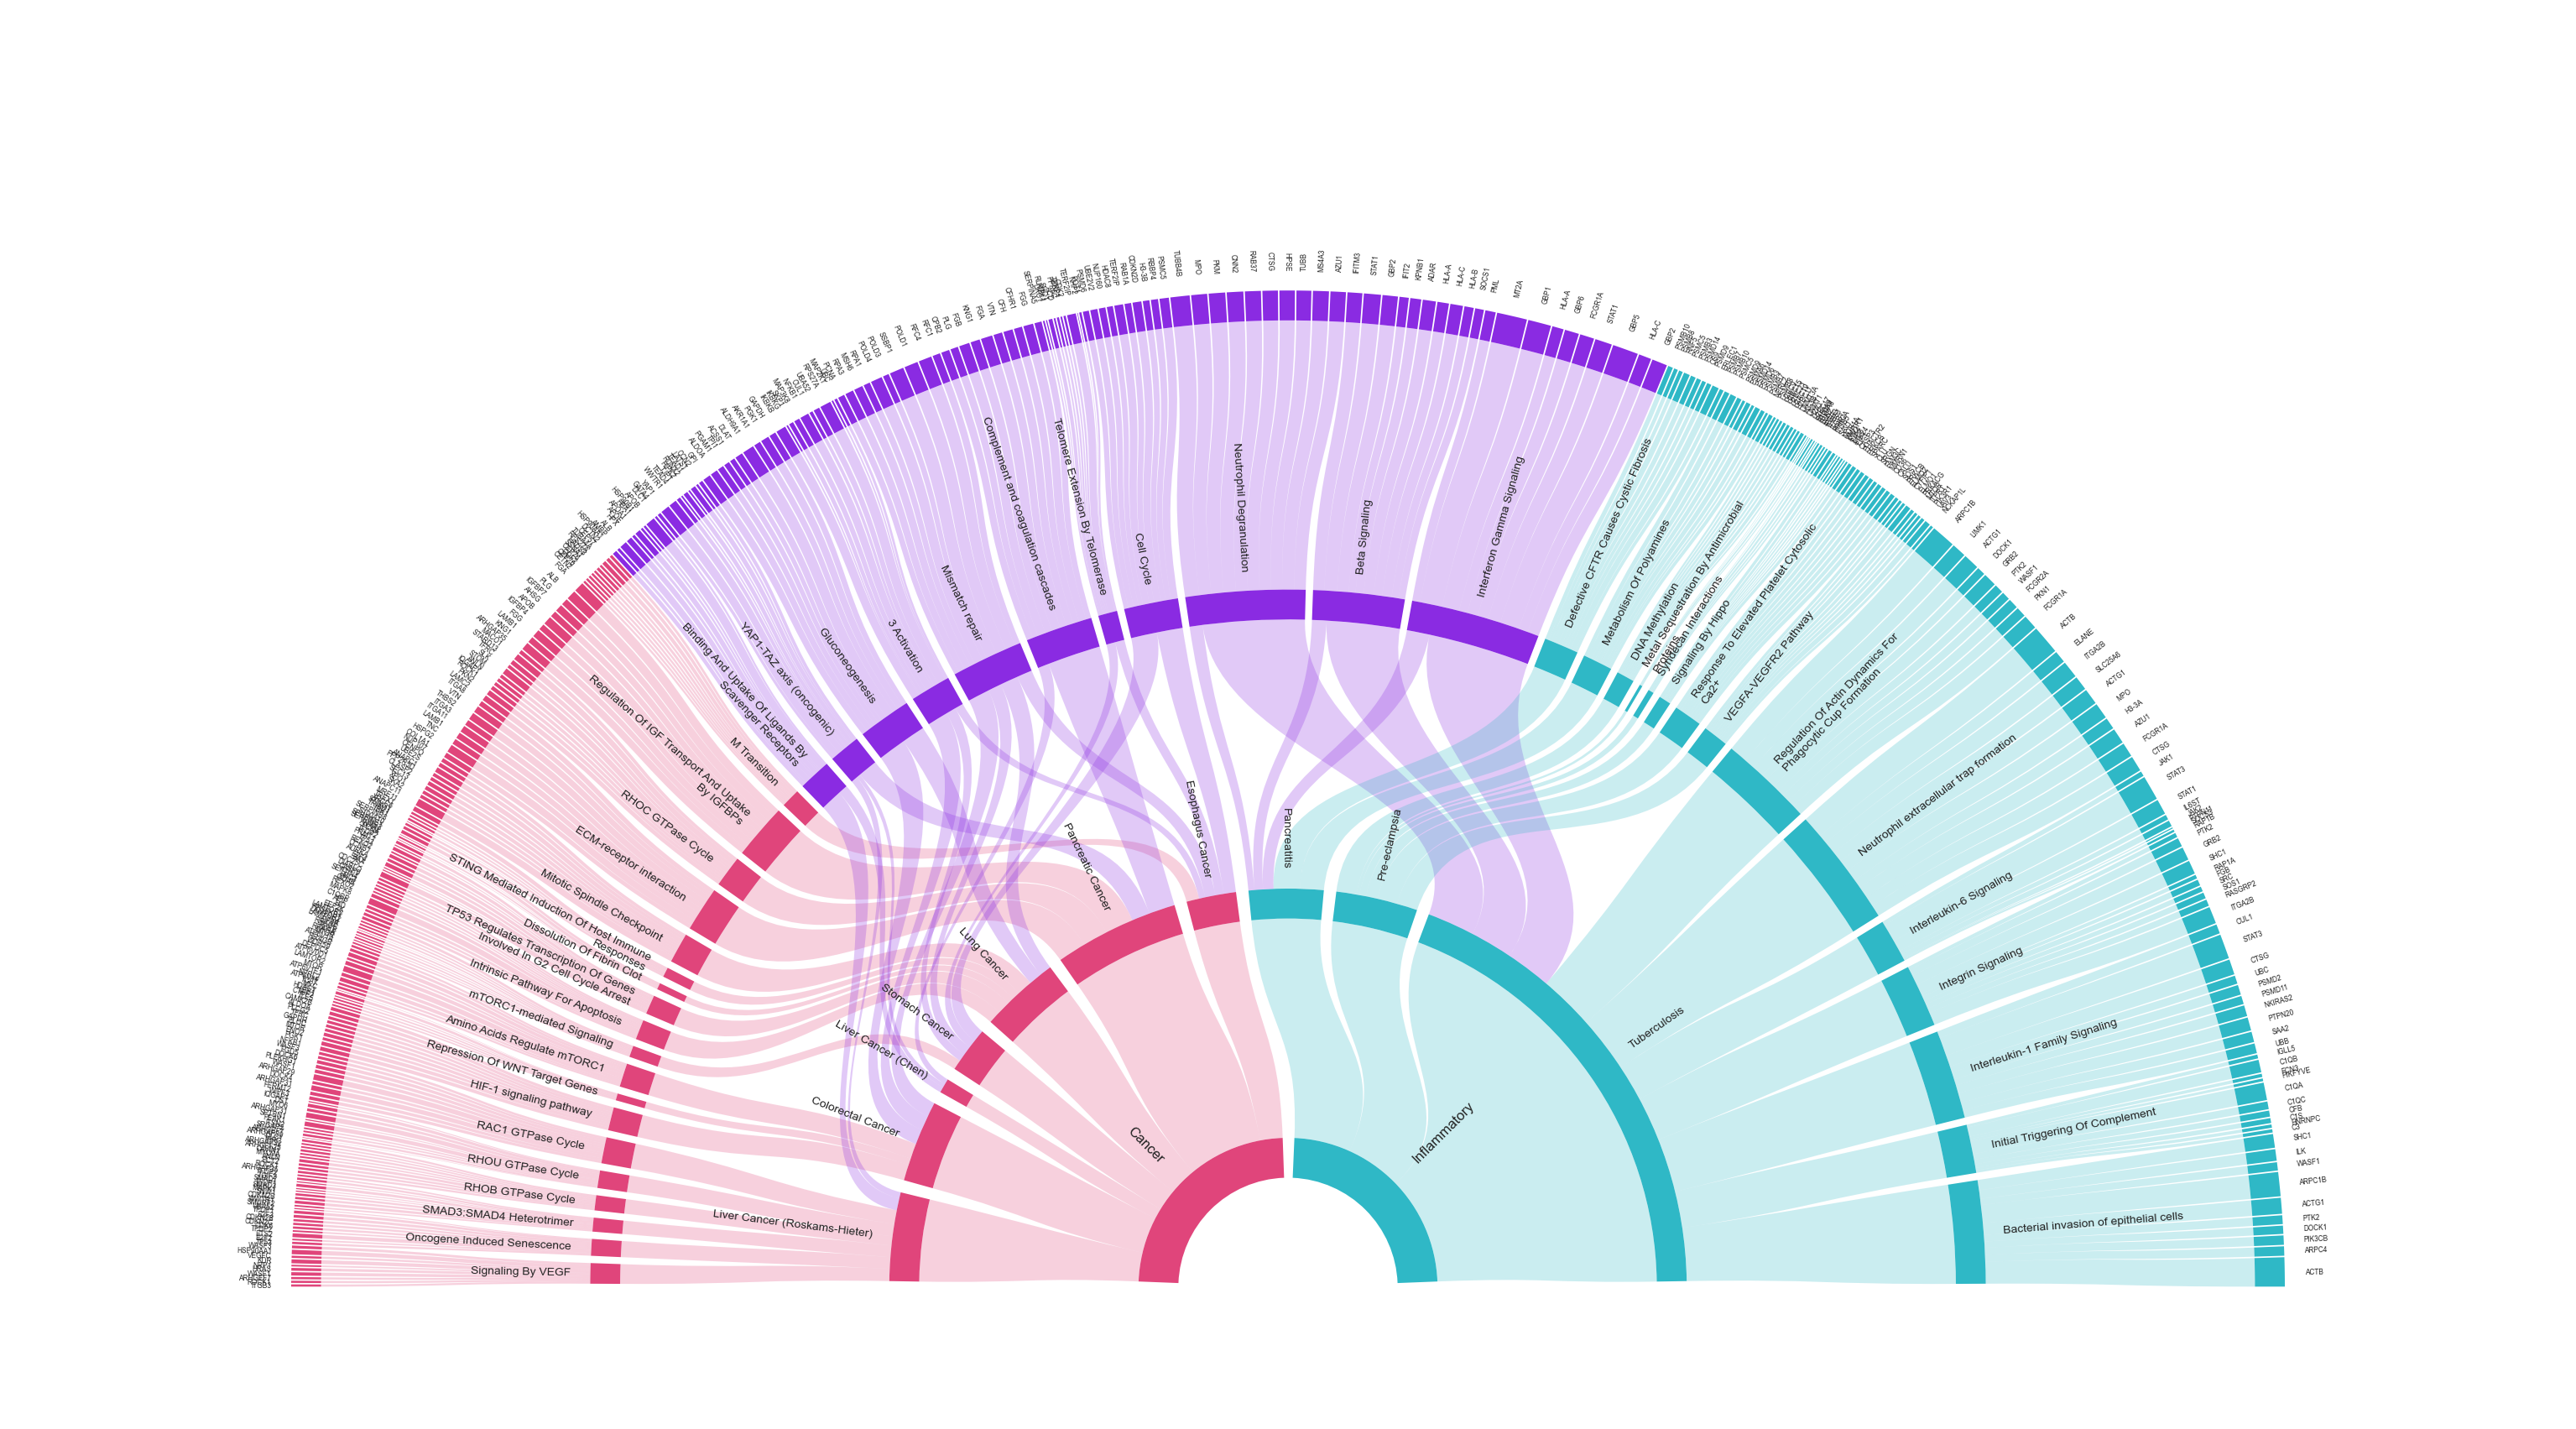

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Wedge
from matplotlib.colors import LinearSegmentedColormap
import textwrap

# Define color gradient: Inflammatory (0.0, Cyan) -> Shared (0.5, Purple) -> Cancer (1.0, Pink)
COLORS = {"cancer": "#e0457b", "inflammatory": "#2fb8c6", "shared": "#8a2be2"}
cmap = LinearSegmentedColormap.from_list("cat_cmap", [COLORS["inflammatory"], COLORS["shared"], COLORS["cancer"]])

GENES_PER_PATHWAY = 10
DEPTH_R = {"category": 0.15, "phenotype": 0.40, "pathway": 0.70, "gene": 1.0}

# 1. Data Preparation & Node Identification
sub = edges.copy()
sub["pid"] = sub["category"] + "/" + sub["phenotype"]

# Differentiate shared (recurring) pathways vs phenotype-unique pathways
sub["tid"] = np.where(sub["recurring"], "pathway::" + sub["term_group"],
                       sub["category"] + "/" + sub["phenotype"] + "/" + sub["term_group"])

# Extract top genes per tid
top_genes = (sub.groupby(["tid", "gene"]).size().rename("n").reset_index()
             .sort_values("n", ascending=False).groupby("tid").head(GENES_PER_PATHWAY))
sub = sub.merge(top_genes[["tid", "gene"]], on=["tid", "gene"])
sub["gid"] = sub["tid"] + "/" + sub["gene"]

# Calculate link weights
def link_weights(parent_col, child_col):
    return sub.groupby([parent_col, child_col])["sample"].nunique().rename("w").reset_index()

all_links = pd.concat([
    link_weights("category", "pid").rename(columns={"category": "src", "pid": "dst"}),
    link_weights("pid", "tid").rename(columns={"pid": "src", "tid": "dst"}),
    link_weights("tid", "gid").rename(columns={"tid": "src", "gid": "dst"})
], ignore_index=True)

# 2. Strict Flow Conservation
in_w = all_links.groupby("dst")["w"].sum()
out_w = all_links.groupby("src")["w"].sum()
nodes = set(all_links["src"]).union(set(all_links["dst"]))
node_weights = {n: max(in_w.get(n, 0), out_w.get(n, 0)) for n in nodes}

# 3. Hierarchical Sharing Score Calculation (0.0 to 1.0)
node_scores = {"cancer": 1.0, "inflammatory": 0.0}

# Level 1: Phenotypes (Bound to category)
for p in sub["pid"].unique():
    cat = sub.loc[sub["pid"] == p, "category"].iloc[0]
    node_scores[p] = 1.0 if cat == "cancer" else 0.0

# Level 2: Pathways (tid)
for t in sub["tid"].unique():
    rows = sub.loc[sub["tid"] == t]
    cats = rows["category"].unique()
    is_rec = rows["recurring"].iloc[0] or ("pathway::" in t)
    
    if len(cats) > 1:
        # Cross-category shared pathway -> Exact center (Pure Purple: 0.5)
        n_cancer = (rows["category"] == "cancer").sum()
        node_scores[t] = 0.5 + 0.1 * ((n_cancer / len(rows)) - 0.5)
    elif is_rec:
        # Shared across phenotypes within category -> Shifted toward center
        node_scores[t] = 0.68 if cats[0] == "cancer" else 0.32
    else:
        # Phenotype-unique pathway -> Outer boundary
        node_scores[t] = 1.0 if cats[0] == "cancer" else 0.0

# Level 3: Genes inherit score from their parent pathway
for g in sub["gid"].unique():
    parent_tid = sub.loc[sub["gid"] == g, "tid"].iloc[0]
    node_scores[g] = node_scores.get(parent_tid, 0.5)

# 4. Layout Generation
def allocate_angles(node_list, start_angle=0, end_angle=np.pi, gap_frac=0.1, parent_angles=None):
    # Primary sort: Disease score / Secondary sort: Spatial angle of parent nodes
    if parent_angles:
        node_list = sorted(node_list, key=lambda x: (node_scores.get(x, 0.5), parent_angles.get(x, 0)))
    else:
        node_list = sorted(node_list, key=lambda x: node_scores.get(x, 0.5))
        
    total_w = sum(node_weights.get(n, 1) for n in node_list)
    gap_total = (end_angle - start_angle) * gap_frac
    usable_angle = (end_angle - start_angle) - gap_total
    gap_per_node = gap_total / max(1, len(node_list))
    
    layout = {}
    curr_angle = start_angle + gap_per_node / 2
    for n in node_list:
        w = node_weights.get(n, 1)
        span = usable_angle * (w / total_w)
        layout[n] = {"start": curr_angle, "end": curr_angle + span, "span": span, "w": w}
        curr_angle += span + gap_per_node
    return layout

cats = ["cancer", "inflammatory"]
phens = list(set(sub["pid"]))
pathways = list(set(sub["tid"]))
genes = list(set(sub["gid"]))

theta_nodes = {}

# Layer 1: Categories
theta_nodes.update(allocate_angles(cats, gap_frac=0.05))

# Layer 2: Phenotypes
cat_angle = {p: theta_nodes[sub.loc[sub["pid"]==p, "category"].iloc[0]]["start"] for p in phens}
theta_nodes.update(allocate_angles(phens, gap_frac=0.10, parent_angles=cat_angle))

# Layer 3: Pathways
path_angle = {}
for t in pathways:
    connected_phens = sub.loc[sub["tid"]==t, "pid"].unique()
    # Compute mean angle of parent phenotypes to minimize edge distance
    path_angle[t] = np.mean([theta_nodes[p]["start"] for p in connected_phens if p in theta_nodes])
theta_nodes.update(allocate_angles(pathways, gap_frac=0.15, parent_angles=path_angle))

# Layer 4: Genes
gene_angle = {g: theta_nodes[sub.loc[sub["gid"]==g, "tid"].iloc[0]]["start"] for g in genes}
theta_nodes.update(allocate_angles(genes, gap_frac=0.20, parent_angles=gene_angle))

out_angles = {n: theta_nodes[n]["start"] for n in theta_nodes}
in_angles = {n: theta_nodes[n]["start"] for n in theta_nodes}

# 5. Visualization
fig, ax = plt.subplots(figsize=(30, 20), facecolor="white")
ax.set_facecolor("white")

def get_node_color(n):
    # Explicitly highlight recurring hubs with shared purple tone if recurring flag is set
    if "pathway::" in n or (n in set(sub["tid"]) and sub.loc[sub["tid"] == n, "recurring"].iloc[0]):
        return COLORS["shared"]
    return cmap(node_scores.get(n, 0.5))

def draw_wedges(node_list, r, width=0.03):
    for n in node_list:
        if n not in theta_nodes: continue
        t = theta_nodes[n]
        ax.add_patch(Wedge((0, 0), r, np.degrees(t["start"]), np.degrees(t["end"]), 
                           width=width, facecolor=get_node_color(n), edgecolor="none"))

draw_wedges(cats, DEPTH_R["category"], width=0.04)
draw_wedges(phens, DEPTH_R["phenotype"])
draw_wedges(pathways, DEPTH_R["pathway"])
draw_wedges(genes, DEPTH_R["gene"])

def ring_of(n):
    if n in cats: return DEPTH_R["category"]
    if n in phens: return DEPTH_R["phenotype"]
    if n in pathways: return DEPTH_R["pathway"]
    return DEPTH_R["gene"]

# Draw Sankey Ribbons
all_links["src_angle"] = all_links["src"].map(lambda x: theta_nodes[x]["start"])
all_links["dst_angle"] = all_links["dst"].map(lambda x: theta_nodes[x]["start"])
all_links = all_links.sort_values(by=["src_angle", "dst_angle"])

for _, row in all_links.iterrows():
    src, dst, w = row["src"], row["dst"], row["w"]
    if src not in theta_nodes or dst not in theta_nodes: continue
    
    src_info, dst_info = theta_nodes[src], theta_nodes[dst]
    
    src_span = src_info["span"] * (w / max(out_w.get(src, 1), 1))
    dst_span = dst_info["span"] * (w / max(in_w.get(dst, 1), 1))
    
    a1_start = out_angles[src]
    a1_end = a1_start + src_span
    out_angles[src] = a1_end
    
    a2_start = in_angles[dst]
    a2_end = a2_start + dst_span
    in_angles[dst] = a2_end
    
    r1, r2 = ring_of(src), ring_of(dst) - 0.03
    
    # Calculate bezier control points for curved ribbons
    rc = (r1 + r2) / 2
    p00 = (r1 * np.cos(a1_start), r1 * np.sin(a1_start))
    c00 = (rc * np.cos(a1_start), rc * np.sin(a1_start))
    c10 = (rc * np.cos(a2_start), rc * np.sin(a2_start))
    p10 = (r2 * np.cos(a2_start), r2 * np.sin(a2_start))
    
    p11 = (r2 * np.cos(a2_end), r2 * np.sin(a2_end))
    c11 = (rc * np.cos(a2_end), rc * np.sin(a2_end))
    c01 = (rc * np.cos(a1_end), rc * np.sin(a1_end))
    p01 = (r1 * np.cos(a1_end), r1 * np.sin(a1_end))
    
    # Dynamically interpolate points along the arc to prevent straight-line chord gaps
    # Number of points is proportional to the arc span, minimum 5 points
    N_ARC = max(5, int(np.degrees(max(src_span, dst_span)) * 2))
    a1_angles = np.linspace(a1_start, a1_end, N_ARC)
    a2_angles = np.linspace(a2_start, a2_end, N_ARC)
    
    verts = [p00, c00, c10, p10]
    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    
    # Follow the destination arc curvature
    for a in a2_angles[1:]:
        verts.append((r2 * np.cos(a), r2 * np.sin(a)))
        codes.append(Path.LINETO)
        
    # Bezier curve back to source
    verts.extend([c11, c01, p01])
    codes.extend([Path.CURVE4, Path.CURVE4, Path.CURVE4])
    
    # Follow the source arc curvature backwards to close the polygon seamlessly
    for a in reversed(a1_angles[:-1]):
        verts.append((r1 * np.cos(a), r1 * np.sin(a)))
        codes.append(Path.LINETO)
        
    verts.append((0, 0)) # Placeholder coordinate for CLOSEPOLY
    codes.append(Path.CLOSEPOLY)
    
    if "pathway::" in dst or "pathway::" in src:
        ribbon_color = COLORS["shared"]
    else:
        blended_score = (node_scores.get(src, 0.5) + node_scores.get(dst, 0.5)) / 2
        ribbon_color = cmap(blended_score)
        
    ax.add_patch(PathPatch(Path(verts, codes), facecolor=ribbon_color, edgecolor="none", alpha=0.25))

# 5. Labeling with Radial Alignment and Name Cleaning
LABEL_CFG = {
    "category": (12, DEPTH_R["category"] * 1.2),
    "phenotype": (10, DEPTH_R["phenotype"] + 0.02),
    "pathway": (10, DEPTH_R["pathway"] + 0.02),
    "gene": (6, DEPTH_R["gene"] + 0.02)
}

DISPLAY_NAME = {
    'Tuberculosis': 'Tuberculosis', 'Pancreatitis': 'Pancreatitis', 'Pancreatic_Cancer': 'Pancreatic Cancer',
    'Pre-eclampsia': 'Pre-eclampsia', 'Colorectal_Cancer': 'Colorectal Cancer', 'Lung_Cancer': 'Lung Cancer',
    'Esophagus_Cancer': 'Esophagus Cancer', 'Stomach_Cancer': 'Stomach Cancer',
    'Liver_Cancer_Roskams-Hieter': 'Liver Cancer (Roskams-Hieter)', 'Liver_Cancer_Chen': 'Liver Cancer (Chen)',
}

def clean_label(label, group_name):
    if group_name == "category":
        return label.capitalize()
    
    elif group_name == "phenotype":
        name = label.split("/")[-1]
        return DISPLAY_NAME.get(name, name.replace("_", " "))
        
    elif group_name == "pathway":
        label = label.split("/")[-1].replace("pathway::", "")
        name = strip_reactome_code(label)
        name = textwrap.fill(name, width=40)
        return name
        
    else: # gene
        return label.split("/")[-1]

for group_name, items in [("category", cats), ("phenotype", phens), ("pathway", pathways), ("gene", genes)]:
    fontsize, r = LABEL_CFG[group_name]
    
    for n in items:
        if n not in theta_nodes: 
            continue
            
        t_mid = (theta_nodes[n]["start"] + theta_nodes[n]["end"]) / 2
        rot_deg = np.degrees(t_mid)
        
        if rot_deg < 90 or rot_deg > 270:
            ha = "left"
            rot = rot_deg
        else:
            ha = "right"
            rot = rot_deg - 180
            
        va = "center"
        display_name = clean_label(n, group_name)
        
        # [수정] Gene 라벨 생략(Filtering) 로직 제거. 모든 유전자가 표기됩니다.
        
        ax.text(r * np.cos(t_mid), r * np.sin(t_mid), display_name, 
                rotation=rot, ha=ha, va=va, fontsize=fontsize, 
                color="#222222", rotation_mode="anchor")

ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-0.1, 1.25)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.show()